In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import signal
import copy
import pyfonts
import h5py

import numpy as np
from scipy.signal import iirpeak, freqz
import matplotlib.pyplot as plt

# Set global font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

In [5]:
#Set global plotting parameters
mpl.rcParams['agg.path.chunksize'] = 10000
mpl.rcParams['figure.dpi'] = 600

SIZE_DEFAULT = 10
plt.rcParams["font.size"] = SIZE_DEFAULT
plt.rcParams["axes.titlesize"] = SIZE_DEFAULT + 6
plt.rcParams["axes.labelsize"] = SIZE_DEFAULT + 4
plt.rcParams["xtick.labelsize"] = SIZE_DEFAULT
plt.rcParams["ytick.labelsize"] = SIZE_DEFAULT

fig_width = 6  # inches
fig_height = 3.5  # inches
plt.rcParams["figure.figsize"] = (fig_width, fig_height)

wong_colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

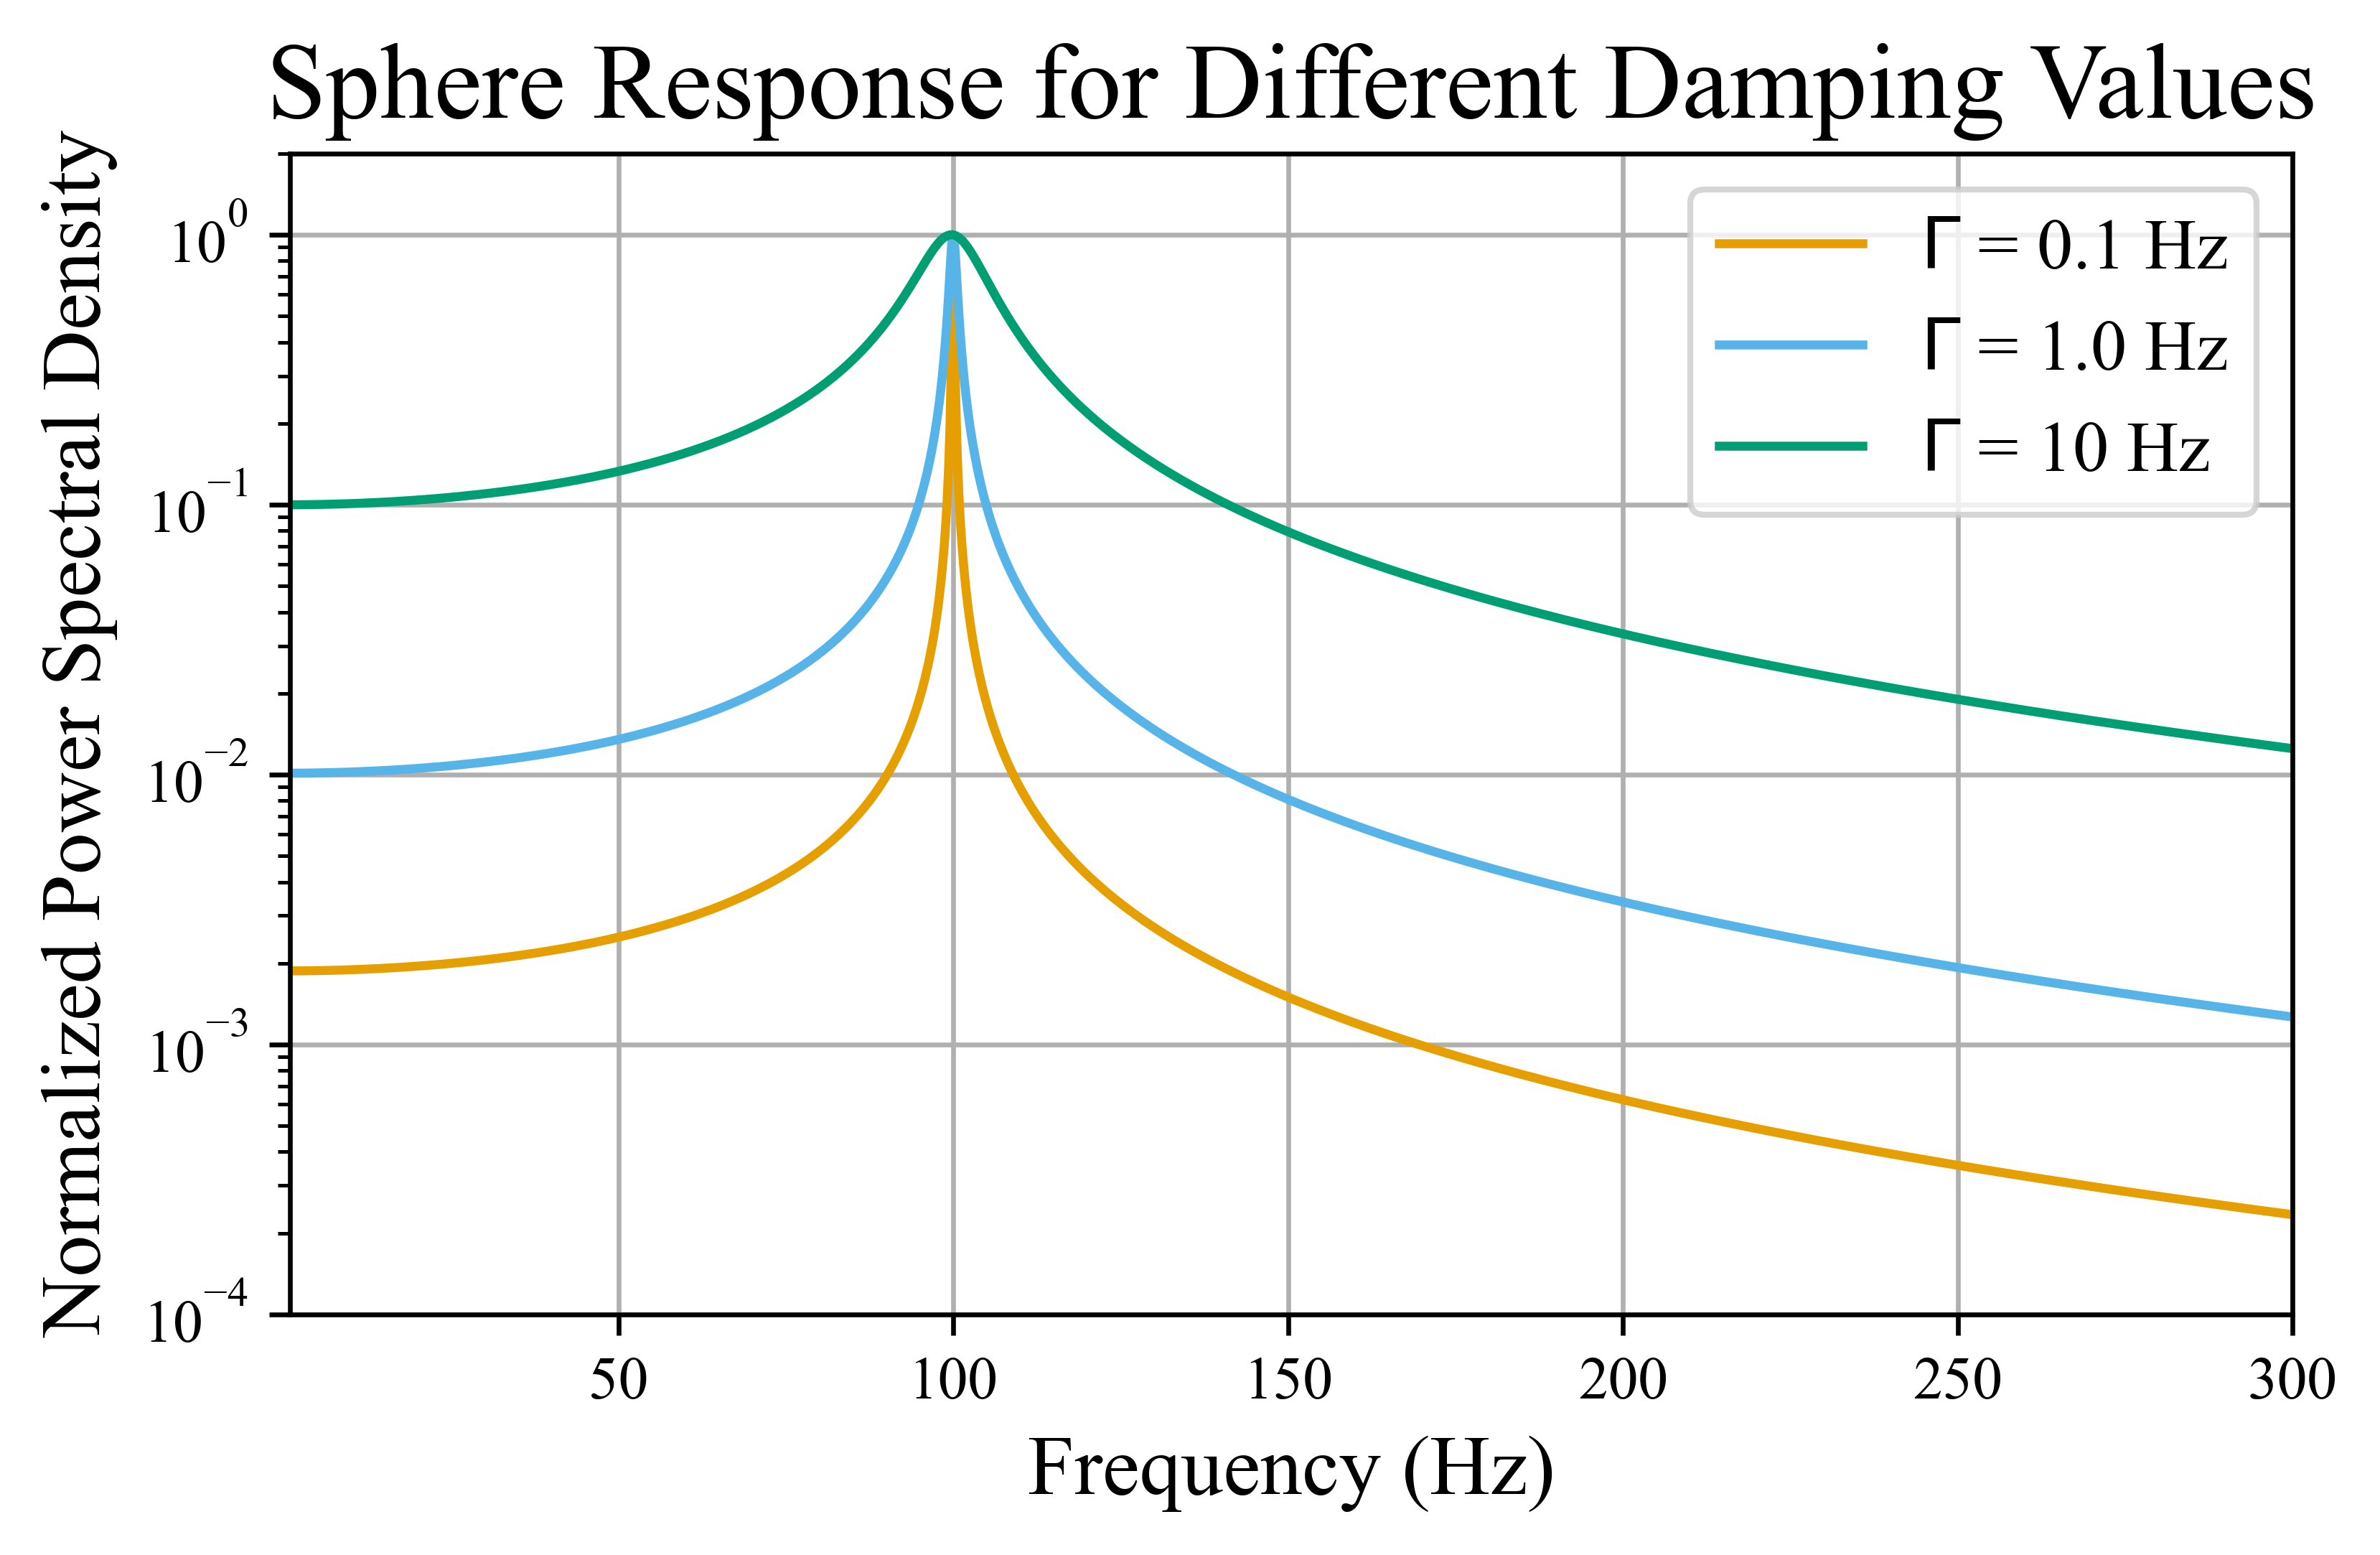

<Figure size 3600x2100 with 0 Axes>

<Figure size 3600x2100 with 0 Axes>

In [8]:
# Define Lorentzian function
def lorentzian(f, f0, gamma):
    return 1/((f0**2 - f**2)**2 + f**2 * (gamma)**2)

# Parameters for the Lorentzian
f0_lorentzian = 100.0  # Resonance frequency in Hz
gamma_values = [0.1, 1.0, 10]  # Linewidth values
frequencies_lorentzian = np.linspace(1, 1000, 5000)  # Frequency range for plotting

plt.figure()

# Plot the Lorentzian amplitude for each gamma value (in dB)
for gamma_lorentzian in gamma_values:
    amplitude_lorentzian = np.sqrt(lorentzian(frequencies_lorentzian, f0_lorentzian, gamma_lorentzian))
    amplitude_lorentzian_lin = (amplitude_lorentzian / np.max(amplitude_lorentzian))
    amplitude_lorentzian_db = 10 * np.log10(amplitude_lorentzian / np.max(amplitude_lorentzian))  # Convert to dB and normalize
    plt.semilogy(frequencies_lorentzian, amplitude_lorentzian_lin, color=wong_colors[gamma_values.index(gamma_lorentzian)], label=f'$\Gamma$ = {gamma_lorentzian} Hz')
plt.xlim(1, 300)
plt.ylim(1e-4, 2)
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Normalized Power Spectral Density', fontsize=14)
plt.title('Sphere Response for Different Damping Values', fontsize=18)
plt.legend(fontsize=12)
plt.grid()
plt.show()

plt.figure()
